# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [7]:
#Type your code here
!pip install mlflow==2.19.0 dagshub
import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import dagshub
import os

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [8]:
path = kagglehub.competition_download('house-prices-advanced-regression-techniques')
file_path = os.path.join(path, 'train.csv')

df = pd.read_csv(file_path)

print("Dataset berhasil dimuat dari:", path)
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
display(df.head())

Dataset berhasil dimuat dari: /root/.cache/kagglehub/competitions/house-prices-advanced-regression-techniques
Jumlah baris: 1460, Jumlah kolom: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


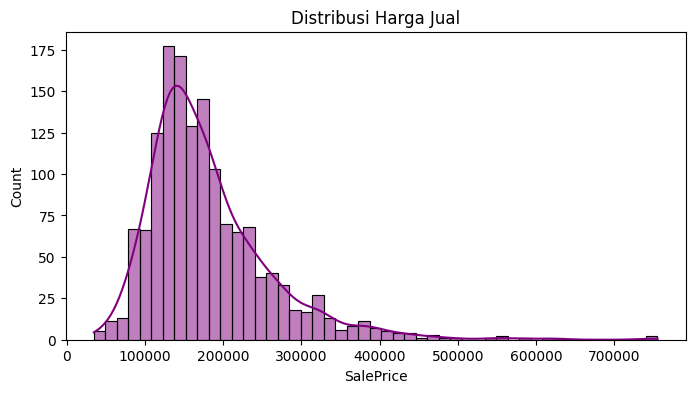

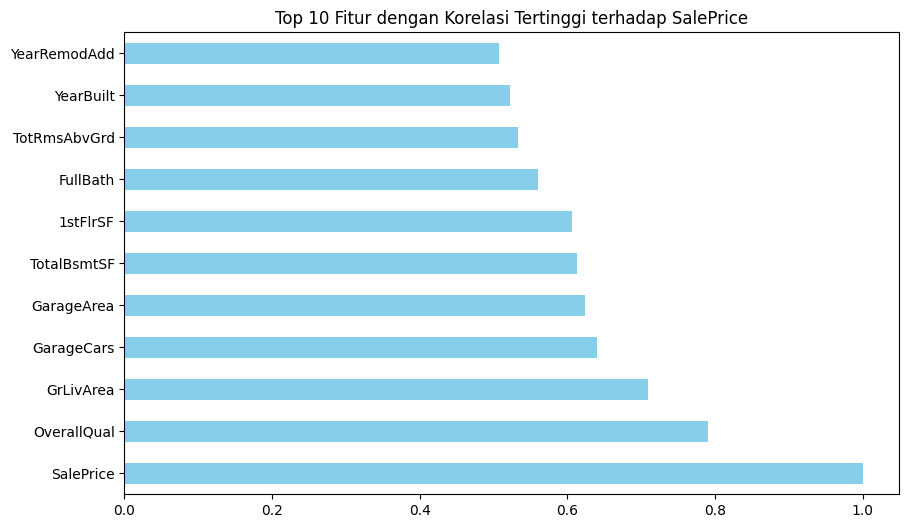

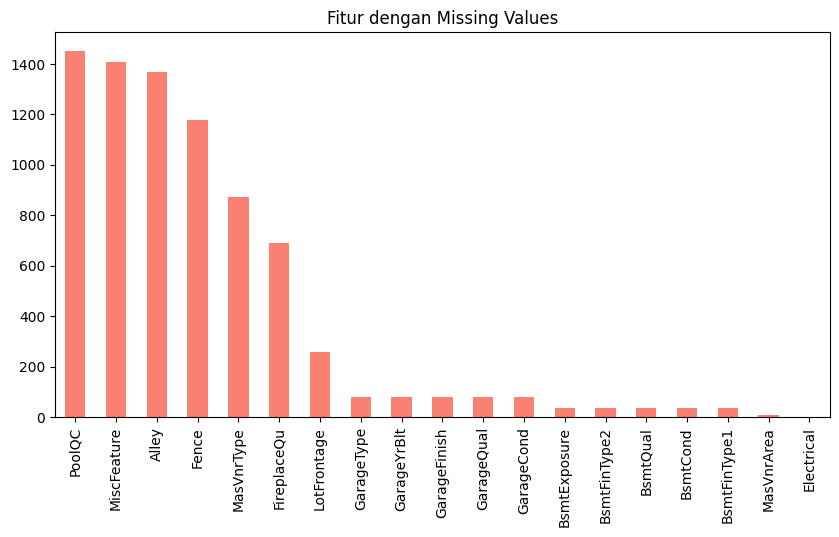

In [9]:
#Type your code here
display(df.describe().T.head(10))

plt.figure(figsize=(8, 4))
sns.histplot(df['SalePrice'], kde=True, color='purple')
plt.title('Distribusi Harga Jual')
plt.show()

plt.figure(figsize=(10, 6))
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
corr.head(11).plot(kind='barh', color='skyblue')
plt.title('Top 10 Fitur dengan Korelasi Tertinggi terhadap SalePrice')
plt.show()

plt.figure(figsize=(10, 5))
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.plot(kind='bar', color='salmon')
plt.title('Fitur dengan Missing Values')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [10]:
from sklearn.preprocessing import StandardScaler
# 1. Menangani Data Kosong (Missing Values)
# Mengisi fitur kategorikal dengan 'None'
cat_cols_with_na = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in cat_cols_with_na:
    df[col] = df[col].fillna('None')

# Mengisi fitur numerik dengan median
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

# 2. Menghapus Data Duplikat
df = df.drop_duplicates()

# 3. Normalisasi atau Standarisasi Fitur
# Normalisasi target (Log Transform) agar distribusi lebih normal
df['SalePrice'] = np.log1p(df['SalePrice'])

# Standarisasi fitur numerik menggunakan StandardScaler
scaler = StandardScaler()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('SalePrice')
df[num_cols] = scaler.fit_transform(df[num_cols])

# 4. Deteksi dan Penanganan Outlier
# Menggunakan IQR pada GrLivArea
Q1 = df['GrLivArea'].quantile(0.25)
Q3 = df['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['GrLivArea'] >= (Q1 - 1.5 * IQR)) & (df['GrLivArea'] <= (Q3 + 1.5 * IQR))]

# 5. Encoding Data Kategorikal
# Menggunakan One-Hot Encoding
df = pd.get_dummies(df)

# 6. Binning (Pengelompokan Data)
# Mengelompokkan YearBuilt menjadi dekade

bins = [1870, 1900, 1920, 1940, 1960, 1980, 2000, 2025]
df['YearBuilt_Bin'] = pd.cut(df['YearBuilt'], bins=bins, labels=False)

print("Preprocessing selesai!")
print(f"Bentuk data final: {df.shape}")

Preprocessing selesai!
Bentuk data final: (1429, 300)
